# Examen 3 - Estadistica Aplicada
## Pregunta 1: Inferencia y Diagnostico Econometrico
**Empresa:** CargaNacional S.A. — Transporte y Logistica
**Profesor:** Milton Martinez | **Fecha:** 20 de Septiembre de 2026

**Objetivo:** Estimar un modelo de Regresion Lineal Multiple (MCO) que explique el costo de mantenimiento correctivo de una flota de 500 camiones, validar que cumple sus supuestos e interpretar los resultados para la direccion de finanzas.


### 1. Contexto del problema
La empresa CargaNacional S.A. tiene problemas con la variabilidad de los costos de mantenimiento correctivo de su flota de camiones. La direccion de finanzas quiere entender qué factores —como la edad de los camiones, los kilometros recorridos, la carga transportada, el tipo de ruta y si tienen plan preventivo— explican esos costos.

El objetivo aqui no es predecir, sino **entender** las relaciones. Para eso vamos a construir un modelo de regresion lineal, revisar que cumple sus supuestos y luego darle una lectura economica clara para que la gerencia tome decisiones sobre renovacion de flota.

Las variables disponibles son:
- **edad_meses**: Tiempo de operacion del camion desde su compra (en meses)
- **km_recorridos**: Distancia total recorrida durante el mes (en miles de kilometros)
- **carga_promedio**: Peso promedio transportado por viaje (en toneladas)
- **tipo_ruta**: Clasificacion de la ruta (*Urbana, Larga Distancia*)
- **plan_preventivo**: Indica si el camion forma parte del programa de mantenimiento preventivo (*Si, No*)
- **costo_mantenimiento** *(variable objetivo)*: Gasto total en reparaciones y mantenimiento correctivo (en dolares)


### 2. Carga de datos y exploracion inicial
Primero cargamos la base `flota_mantenimiento.csv` y la revisamos por encima: cuantas filas tiene, que tipo es cada columna, si hay nulos y como se distribuyen los valores. Esto es para no correr un modelo a ciegas.


In [28]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Cargar datos
df = pd.read_csv('flota_mantenimiento.csv')

print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())
print('\nEstadisticas descriptivas:')
print(df.describe().round(2))
print('\nDistribucion de variables categoricas:')
print('Tipo de ruta:')
print(df['tipo_ruta'].value_counts())
print('\nPlan preventivo:')
print(df['plan_preventivo'].value_counts())

Dimensiones: (500, 6)

Tipos de datos:
edad_meses             float64
km_recorridos          float64
carga_promedio         float64
tipo_ruta               object
plan_preventivo         object
costo_mantenimiento    float64
dtype: object

Valores nulos:
edad_meses             0
km_recorridos          0
carga_promedio         0
tipo_ruta              0
plan_preventivo        0
costo_mantenimiento    0
dtype: int64

Estadisticas descriptivas:
       edad_meses  km_recorridos  carga_promedio  costo_mantenimiento
count      500.00         500.00          500.00               500.00
mean        48.15           8.53           18.08              5307.99
std         18.26           2.56            6.01              2038.44
min          6.00           2.00            5.00              1130.51
25%         35.00           6.60           13.88              3701.13
50%         47.00           8.50           18.20              5102.34
75%         60.25          10.20           21.82              65

### 3. Analisis exploratorio: correlaciones y relaciones
Antes del modelo miramos como se mueven las variables juntas con la matriz de correlacion. Si dos variables explicativas estan muy pegadas, despues cuesta saber cual es la que realmente pesa en el costo.


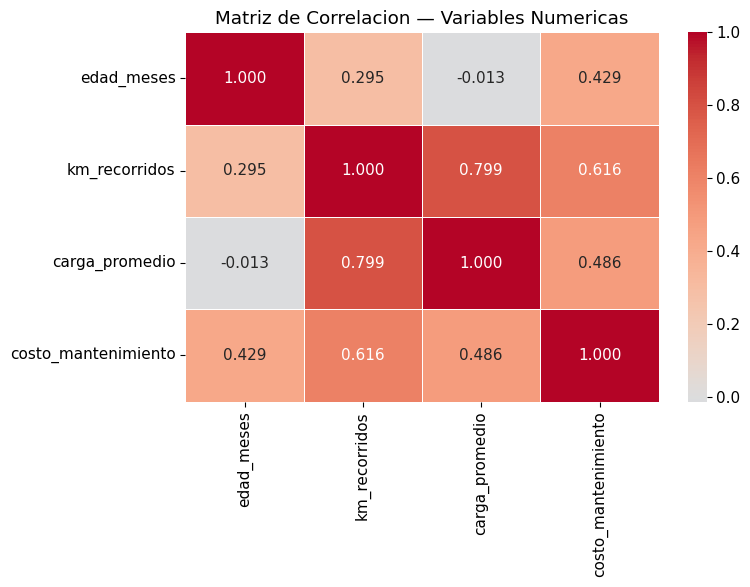


Correlaciones con costo_mantenimiento:
costo_mantenimiento    1.000000
km_recorridos          0.615659
carga_promedio         0.486192
edad_meses             0.429040
Name: costo_mantenimiento, dtype: float64


In [29]:
numeric_cols = ['edad_meses', 'km_recorridos', 'carga_promedio', 'costo_mantenimiento']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=0.5)
plt.title('Matriz de Correlacion — Variables Numericas')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con costo_mantenimiento:')
print(corr_matrix['costo_mantenimiento'].sort_values(ascending=False))

### 4. Graficos de dispersion para evaluar linealidad
Aca graficamos cada variable contra el costo para ver si la relacion se ve mas o menos recta. Tambien comparamos el costo por ruta y por plan, y miramos el histograma del costo.


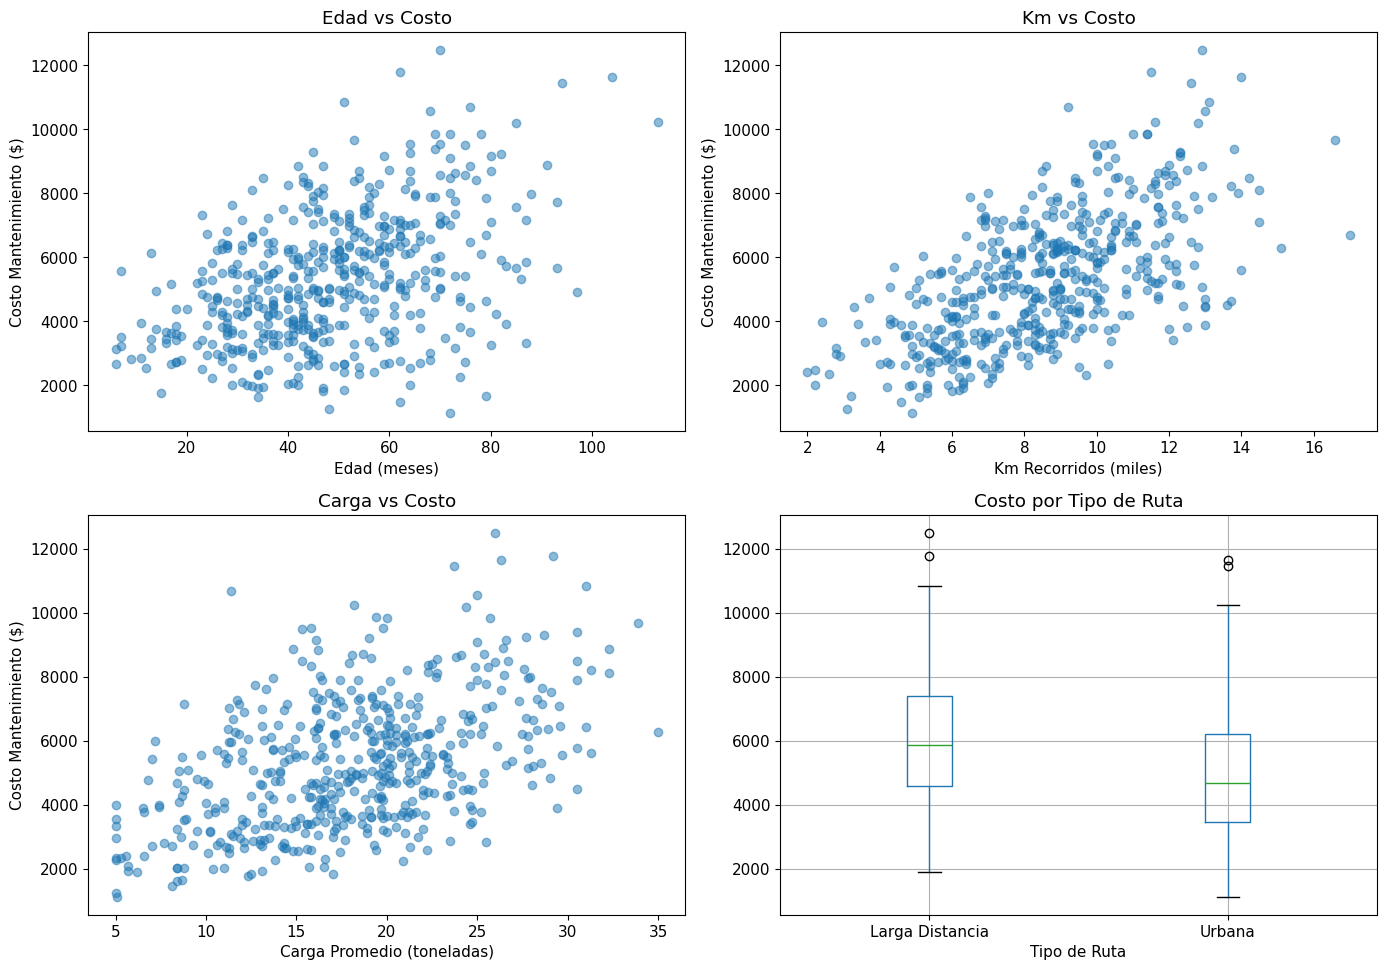


Costo promedio por tipo de ruta:
tipo_ruta
Larga Distancia    6009.50
Urbana             4881.67
Name: costo_mantenimiento, dtype: float64

Costo promedio por plan preventivo:
plan_preventivo
No    5979.73
Si    3770.06
Name: costo_mantenimiento, dtype: float64


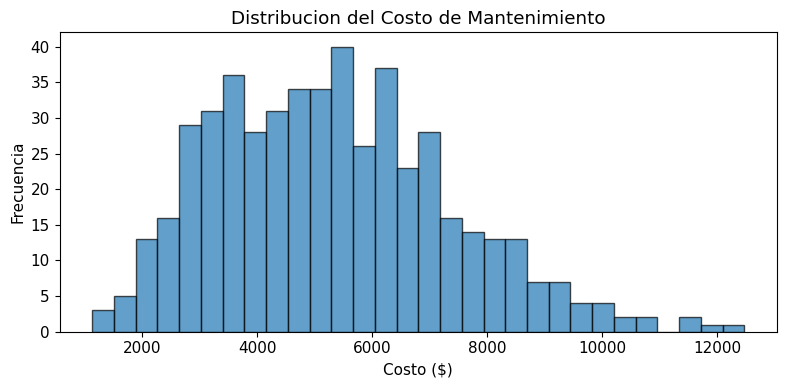

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dispersión edad vs costo
axes[0, 0].scatter(df['edad_meses'], df['costo_mantenimiento'], alpha=0.5)
axes[0, 0].set_xlabel('Edad (meses)')
axes[0, 0].set_ylabel('Costo Mantenimiento ($)')
axes[0, 0].set_title('Edad vs Costo')

# Dispersión km vs costo
axes[0, 1].scatter(df['km_recorridos'], df['costo_mantenimiento'], alpha=0.5)
axes[0, 1].set_xlabel('Km Recorridos (miles)')
axes[0, 1].set_ylabel('Costo Mantenimiento ($)')
axes[0, 1].set_title('Km vs Costo')

# Dispersión carga vs costo
axes[1, 0].scatter(df['carga_promedio'], df['costo_mantenimiento'], alpha=0.5)
axes[1, 0].set_xlabel('Carga Promedio (toneladas)')
axes[1, 0].set_ylabel('Costo Mantenimiento ($)')
axes[1, 0].set_title('Carga vs Costo')

# Boxplot por tipo de ruta
df.boxplot(column='costo_mantenimiento', by='tipo_ruta', ax=axes[1, 1])
axes[1, 1].set_title('Costo por Tipo de Ruta')
axes[1, 1].set_xlabel('Tipo de Ruta')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Costo promedio por categorias
print('\nCosto promedio por tipo de ruta:')
print(df.groupby('tipo_ruta')['costo_mantenimiento'].mean().round(2))
print('\nCosto promedio por plan preventivo:')
print(df.groupby('plan_preventivo')['costo_mantenimiento'].mean().round(2))

# Histograma del costo
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['costo_mantenimiento'], bins=30, edgecolor='black', alpha=0.7)
ax.set_title('Distribucion del Costo de Mantenimiento')
ax.set_xlabel('Costo ($)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 5. Estimacion del modelo inicial (MCO)
Corremos una primera regresion con todas las variables. Las de texto (ruta y plan) las pasamos a 0/1 con dummies usando drop_first=True para no duplicar la constante, y agregamos la constante con add_constant().


In [31]:
# Codificar variables categoricas
df_init = pd.get_dummies(df, columns=['tipo_ruta', 'plan_preventivo'], drop_first=True).astype(float)

print('Columnas despues de crear dummies:')
print(df_init.columns.tolist())

X_init = df_init.drop('costo_mantenimiento', axis=1)
X_init = sm.add_constant(X_init)
y_init = df_init['costo_mantenimiento']

modelo_init = sm.OLS(y_init, X_init).fit()
print(modelo_init.summary())

Columnas despues de crear dummies:
['edad_meses', 'km_recorridos', 'carga_promedio', 'costo_mantenimiento', 'tipo_ruta_Urbana', 'plan_preventivo_Si']
                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.823
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     460.1
Date:                 Thu, 24 Sep 2026   Prob (F-statistic):          2.89e-183
Time:                         23:05:14   Log-Likelihood:                -4085.7
No. Observations:                  500   AIC:                             8183.
Df Residuals:                      494   BIC:                             8209.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                         coef    std err          

### 6. Diagnostico de supuestos del modelo inicial
Para que la regresion valga hay que revisar supuestos. Miramos normalidad de residuos con Jarque-Bera, homocedasticidad con Breusch-Pagan y colinealidad con VIF (preocupa si pasa de 10). La linealidad ya la miramos en los graficos.


In [32]:
residuales_init = modelo_init.resid
valores_ajustados_init = modelo_init.fittedvalues

# --- 1. Normalidad de residuos ---
jb_init = stats.jarque_bera(residuales_init)
shapiro_init = stats.shapiro(residuales_init[:500])

print('=== NORMALIDAD DE RESIDUOS ===')
print(f'Jarque-Bera: estadistico={jb_init[0]:.4f}, p-value={jb_init[1]:.6f}')
print(f'Shapiro-Wilk: estadistico={shapiro_init[0]:.4f}, p-value={shapiro_init[1]:.6f}')

if jb_init[1] < 0.05:
    print('>> El test de Jarque-Bera RECHAZA la normalidad (p < 0.05)')
else:
    print('>> El test de Jarque-Bera NO rechaza la normalidad')

# --- 2. Homocedasticidad ---
bp_init = het_breuschpagan(residuales_init, modelo_init.model.exog)
print('\n=== HOMOCEDASTICIDAD ===')
print(f'Breusch-Pagan: estadistico={bp_init[0]:.4f}, p-value={bp_init[1]:.6f}')
if bp_init[1] < 0.05:
    print('>> El test de Breusch-Pagan RECHAZA homocedasticidad (p < 0.05)')
else:
    print('>> El test de Breusch-Pagan NO rechaza homocedasticidad')

# --- 3. Multicolinealidad (VIF) ---
vif_init = pd.DataFrame({
    'Variable': X_init.columns,
    'VIF': [variance_inflation_factor(X_init.values, i) for i in range(X_init.shape[1])]
})
print('\n=== MULTICOLINEALIDAD (VIF) ===')
print(vif_init.to_string(index=False))

print('\n=== RESUMEN ===')
if jb_init[1] < 0.05:
    print('- Normalidad: PROBLEMA detectado')
else:
    print('- Normalidad: OK')
if bp_init[1] < 0.05:
    print('- Homocedasticidad: PROBLEMA detectado')
else:
    print('- Homocedasticidad: OK')
vif_max = vif_init.loc[vif_init['Variable'] != 'const', 'VIF'].max()
if vif_max > 10:
    print(f'- Multicolinealidad: PROBLEMA (VIF max = {vif_max:.2f})')
else:
    print(f'- Multicolinealidad: OK (VIF max = {vif_max:.2f}')

=== NORMALIDAD DE RESIDUOS ===
Jarque-Bera: estadistico=9.8810, p-value=0.007151
Shapiro-Wilk: estadistico=0.9929, p-value=0.017538
>> El test de Jarque-Bera RECHAZA la normalidad (p < 0.05)

=== HOMOCEDASTICIDAD ===
Breusch-Pagan: estadistico=12.1521, p-value=0.032761
>> El test de Breusch-Pagan RECHAZA homocedasticidad (p < 0.05)

=== MULTICOLINEALIDAD (VIF) ===
          Variable       VIF
             const 18.484409
        edad_meses  1.361594
     km_recorridos  3.743115
    carga_promedio  3.434664
  tipo_ruta_Urbana  1.013598
plan_preventivo_Si  1.014353

=== RESUMEN ===
- Normalidad: PROBLEMA detectado
- Homocedasticidad: PROBLEMA detectado
- Multicolinealidad: OK (VIF max = 3.74


### 7. Visualizacion de residuos del modelo inicial
Aparte de los tests, miramos los graficos. Si en residuos vs ajustados se abre como cono, hay heterocedasticidad. En el Q-Q, si se pegan a la diagonal, hay normalidad.


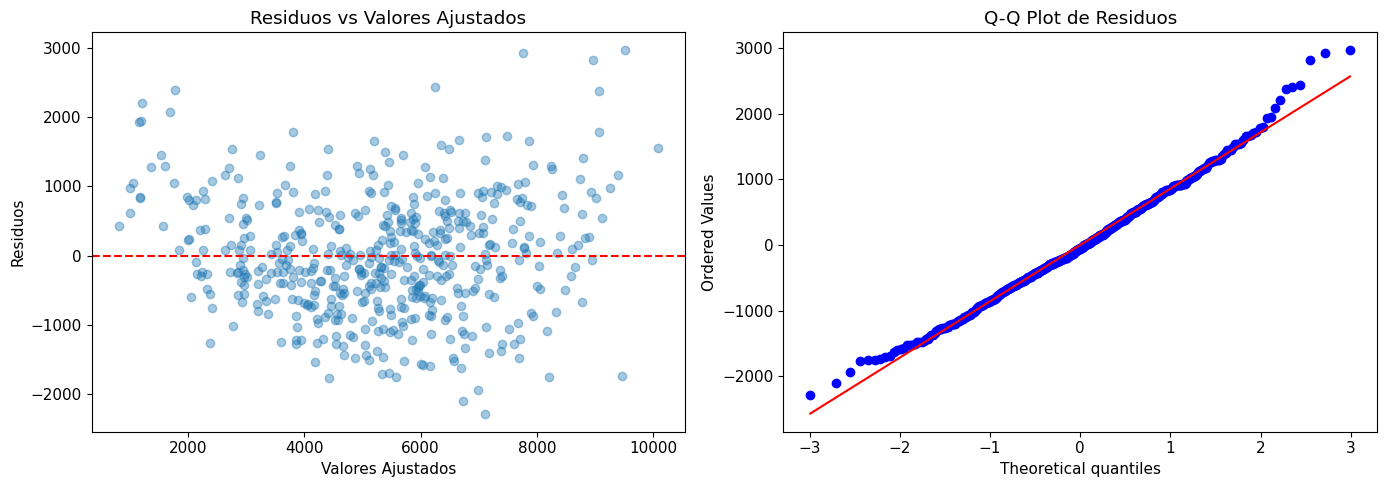

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valores_ajustados_init, residuales_init, alpha=0.4)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Ajustados')

stats.probplot(residuales_init, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos')

plt.tight_layout()
plt.show()

### 8. Decision sobre mejoras al modelo
Viendo lo anterior probamos tres ideas que tienen logica en la operacion:

**1. Ruta larga sin plan:** el plan puede pegar distinto segun la ruta. Creamos una marca para larga distancia sin preventivo.

**2. Edad al cuadrado:** un carro muy viejo no se dana igual, se puede acelerar. Metemos edad^2.

**3. Km por carga:** andar mucho y pesado al tiempo desgasta mas que la suma por separado. Multiplicamos km por carga.

**4. Log:** lo pensamos pero no lo usamos porque el costo no se ve tan asimetrico y no ayudaba en los residuos.


In [34]:
# Crear variables nuevas
df_mej = df.copy()

# Interaccion: ruta larga SIN plan preventivo
df_mej['interaccion_ruta_plan'] = np.where(
    (df_mej['tipo_ruta'] == 'Larga Distancia') & (df_mej['plan_preventivo'] == 'No'), 1, 0
)

# Termino cuadratico de edad
df_mej['edad_meses_sq'] = df_mej['edad_meses'] ** 2

# Interaccion: km_recorridos * carga_promedio
df_mej['km_carga_inter'] = df_mej['km_recorridos'] * df_mej['carga_promedio']

print('Variables nuevas creadas:')
print('- interaccion_ruta_plan: interaccion entre ruta larga y sin plan preventivo')
print('  (refleja el desgaste extra de camiones de larga distancia sin mantenimiento preventivo)')
print('- edad_meses_sq: termino cuadratico de edad')
print('  (captura la aceleracion del desgaste en camiones viejos)')
print('- km_carga_inter: interaccion km/carga')
print('  (captura el efecto combinado de uso intensivo)')

# Codificar dummies
df_mej_dummies = pd.get_dummies(df_mej, columns=['tipo_ruta', 'plan_preventivo'], drop_first=True).astype(float)

X_mej = df_mej_dummies.drop('costo_mantenimiento', axis=1)
X_mej = sm.add_constant(X_mej)
y_mej = df_mej_dummies['costo_mantenimiento']

print('\nVariables del modelo mejorado:')
print(X_mej.columns.tolist())

Variables nuevas creadas:
- interaccion_ruta_plan: interaccion entre ruta larga y sin plan preventivo
  (refleja el desgaste extra de camiones de larga distancia sin mantenimiento preventivo)
- edad_meses_sq: termino cuadratico de edad
  (captura la aceleracion del desgaste en camiones viejos)
- km_carga_inter: interaccion km/carga
  (captura el efecto combinado de uso intensivo)

Variables del modelo mejorado:
['const', 'edad_meses', 'km_recorridos', 'carga_promedio', 'interaccion_ruta_plan', 'edad_meses_sq', 'km_carga_inter', 'tipo_ruta_Urbana', 'plan_preventivo_Si']


### 9. Estimacion del modelo mejorado
Corremos el modelo con esas tres variables extra y lo comparamos con el inicial por R2 ajustado para ver si valio la pena complicarlo.


In [35]:
modelo_mej = sm.OLS(y_mej, X_mej).fit()
print(modelo_mej.summary())

print('\n=== COMPARACION DE MODELOS ===')
print(f'Modelo Inicial  - R2: {modelo_init.rsquared:.4f} | R2 Ajustado: {modelo_init.rsquared_adj:.4f}')
print(f'Modelo Mejorado - R2: {modelo_mej.rsquared:.4f} | R2 Ajustado: {modelo_mej.rsquared_adj:.4f}')

mejora_r2 = modelo_mej.rsquared_adj - modelo_init.rsquared_adj
print(f'Mejora en R2 Ajustado: {mejora_r2:+.4f}')

if modelo_mej.rsquared_adj > modelo_init.rsquared_adj:
    print('>> El modelo mejorado tiene mejor R2 Ajustado')
else:
    print('>> El modelo inicial sigue siendo mejor segun R2 Ajustado')

                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.824
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     286.7
Date:                 Thu, 24 Sep 2026   Prob (F-statistic):          1.32e-179
Time:                         23:05:41   Log-Likelihood:                -4085.1
No. Observations:                  500   AIC:                             8188.
Df Residuals:                      491   BIC:                             8226.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

### 10. Diagnostico del modelo mejorado
Repetimos las mismas pruebas (normalidad, BP y VIF) para ver si con lo nuevo se arreglo algo o quedo igual/peor.


In [36]:
residuales_mej = modelo_mej.resid
valores_ajustados_mej = modelo_mej.fittedvalues

# --- Normalidad ---
jb_mej = stats.jarque_bera(residuales_mej)
shapiro_mej = stats.shapiro(residuales_mej[:500])

print('=== NORMALIDAD (MODELO MEJORADO) ===')
print(f'Jarque-Bera: estadistico={jb_mej[0]:.4f}, p-value={jb_mej[1]:.6f}')
print(f'Shapiro-Wilk: estadistico={shapiro_mej[0]:.4f}, p-value={shapiro_mej[1]:.6f}')
if jb_mej[1] < 0.05:
    print('>> RECHAZA normalidad')
else:
    print('>> NO rechaza normalidad')

# --- Homocedasticidad ---
bp_mej = het_breuschpagan(residuales_mej, modelo_mej.model.exog)
print('\n=== HOMOCEDASTICIDAD (MODELO MEJORADO) ===')
print(f'Breusch-Pagan: estadistico={bp_mej[0]:.4f}, p-value={bp_mej[1]:.6f}')
if bp_mej[1] < 0.05:
    print('>> RECHAZA homocedasticidad')
else:
    print('>> NO rechaza homocedasticidad')

# --- VIF ---
vif_mej = pd.DataFrame({
    'Variable': X_mej.columns,
    'VIF': [variance_inflation_factor(X_mej.values, i) for i in range(X_mej.shape[1])]
})
print('\n=== MULTICOLINEALIDAD VIF (MODELO MEJORADO) ===')
print(vif_mej.to_string(index=False))
vif_max_mej = vif_mej.loc[vif_mej['Variable'] != 'const', 'VIF'].max()
if vif_max_mej > 10:
    print(f'\n>> ALERTA: VIF maximo = {vif_max_mej:.2f} (supera 10)')
else:
    print(f'\n>> VIF maximo = {vif_max_mej:.2f} (dentro de rango aceptable)')


=== NORMALIDAD (MODELO MEJORADO) ===
Jarque-Bera: estadistico=8.8540, p-value=0.011950
Shapiro-Wilk: estadistico=0.9932, p-value=0.023037
>> RECHAZA normalidad

=== HOMOCEDASTICIDAD (MODELO MEJORADO) ===
Breusch-Pagan: estadistico=22.1838, p-value=0.004587
>> RECHAZA homocedasticidad

=== MULTICOLINEALIDAD VIF (MODELO MEJORADO) ===
             Variable        VIF
                const 124.928442
           edad_meses  18.273471
        km_recorridos  10.346873
       carga_promedio  11.084900
interaccion_ruta_plan   4.151564
        edad_meses_sq  17.632890
       km_carga_inter  26.504380
     tipo_ruta_Urbana   3.506025
   plan_preventivo_Si   1.613999

>> ALERTA: VIF maximo = 26.50 (supera 10)


### 11. Graficos de diagnostico del modelo mejorado
Mismos graficos de residuos para el mejorado, para comparar a ojo con el inicial.


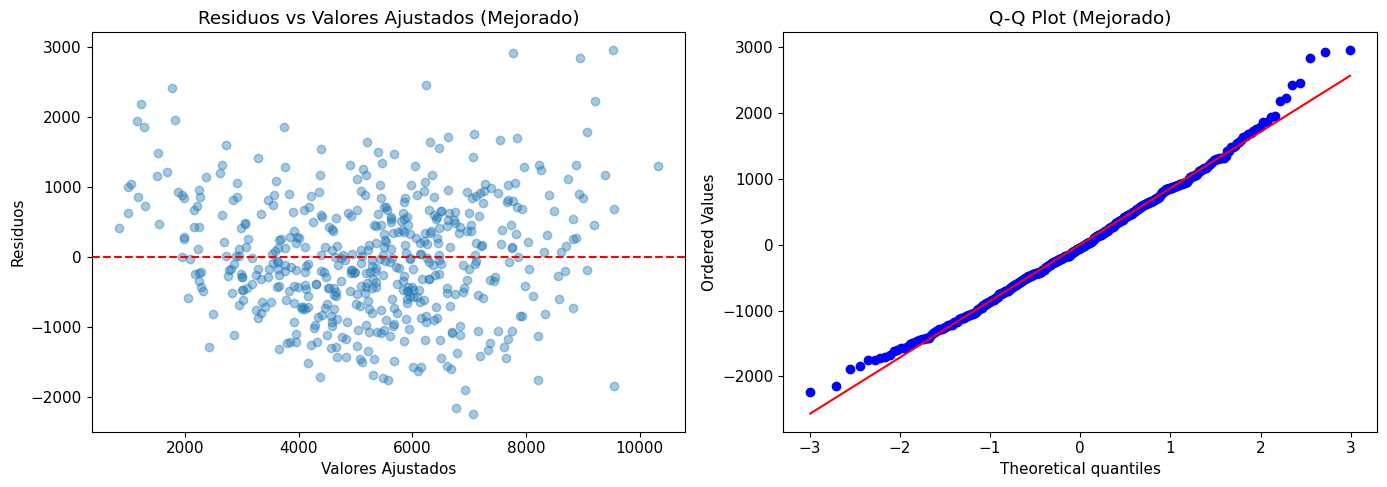

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valores_ajustados_mej, residuales_mej, alpha=0.4)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Ajustados (Mejorado)')

stats.probplot(residuales_mej, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Mejorado)')

plt.tight_layout()
plt.show()

### 12. Seleccion del modelo final
Para elegir miramos R2 ajustado, normalidad, homocedasticidad y VIF. A veces meter mas variables no ayuda y es mejor dejar el modelo sencillo, que fue lo que paso aca.


In [38]:
print('=' * 60)
print('RESUMEN DE SELECCION DEL MODELO FINAL')
print('=' * 60)

print('\nMODELO INICIAL:')
print(f'  R2: {modelo_init.rsquared:.4f} | R2 Aj: {modelo_init.rsquared_adj:.4f}')
print(f'  Normalidad JB p: {jb_init[1]:.4f} | Homocedasticidad BP p: {bp_init[1]:.4f}')
print(f'  VIF maximo (sin const): {vif_init.loc[vif_init["Variable"]!="const", "VIF"].max():.2f}')

print('\nMODELO MEJORADO:')
print(f'  R2: {modelo_mej.rsquared:.4f} | R2 Aj: {modelo_mej.rsquared_adj:.4f}')
print(f'  Normalidad JB p: {jb_mej[1]:.4f} | Homocedasticidad BP p: {bp_mej[1]:.4f}')
print(f'  VIF maximo (sin const): {vif_mej.loc[vif_mej["Variable"]!="const", "VIF"].max():.2f}')

print('\n--- DECISION ---')

mejora_r2a = modelo_mej.rsquared_adj - modelo_init.rsquared_adj
mejora_normalidad = jb_mej[1] - jb_init[1]
mejora_homoc = bp_mej[1] - bp_init[1]
vif_init_nc = vif_init.loc[vif_init["Variable"]!="const", "VIF"].max()
vif_mej_nc = vif_mej.loc[vif_mej["Variable"]!="const", "VIF"].max()

criterios = 0
if mejora_r2a > 0:
    criterios += 1
    print(f'+ R2 Ajustado mejoro en {mejora_r2a:.4f}')
if mejora_normalidad > 0:
    criterios += 1
    print(f'+ Normalidad mejoro (p JB: {jb_init[1]:.4f} -> {jb_mej[1]:.4f})')
if mejora_homoc > 0:
    criterios += 1
    print(f'+ Homocedasticidad mejoro (p BP: {bp_init[1]:.4f} -> {bp_mej[1]:.4f})')
if vif_mej_nc <= vif_init_nc:
    criterios += 1
    print(f'+ Multicolinealidad igual o mejor (VIF max sin const: {vif_init_nc:.2f} -> {vif_mej_nc:.2f})')

if criterios >= 3:
    print('\n>> DECISION: Seleccionar MODELO MEJORADO como definitivo')
    modelo_final = modelo_mej
    X_final = X_mej
    y_final = y_mej
else:
    print('\n>> DECISION: Seleccionar MODELO INICIAL como definitivo')
    modelo_final = modelo_init
    X_final = X_init
    y_final = y_init

# --- CORRECCION: re-estimar el modelo elegido con errores robustos HC3 ---
# El diagnostico muestra rechazo de homocedasticidad (BP p<0.05) y de normalidad
# leve (JB p<0.05, skew~0.3). Con n=500 el TCL sostiene la inferencia sobre la media,
# pero los EE clasicos no son validos bajo heterocedasticidad. Se corrige con HC3.
modelo_final = sm.OLS(y_final, X_final).fit(cov_type='HC3')
print('\nModelo final re-estimado con errores robustos HC3 para inferencia valida:')
print(modelo_final.summary())

RESUMEN DE SELECCION DEL MODELO FINAL

MODELO INICIAL:
  R2: 0.8232 | R2 Aj: 0.8214
  Normalidad JB p: 0.0072 | Homocedasticidad BP p: 0.0328
  VIF maximo (sin const): 3.74

MODELO MEJORADO:
  R2: 0.8237 | R2 Aj: 0.8208
  Normalidad JB p: 0.0120 | Homocedasticidad BP p: 0.0046
  VIF maximo (sin const): 26.50

--- DECISION ---
+ Normalidad mejoro (p JB: 0.0072 -> 0.0120)

>> DECISION: Seleccionar MODELO INICIAL como definitivo

Modelo final re-estimado con errores robustos HC3 para inferencia valida:
                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.823
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     331.2
Date:                 Thu, 24 Sep 2026   Prob (F-statistic):          3.39e-155
Time:                         23:05:58   Log-Likelihood:                -4085.7
No. Observation

### 12b. Evidencia: transformacion log(y) descartada + tabla final de supuestos y Durbin-Watson

El enunciado permite transformaciones si son necesarias. Probamos `log(costo)` de forma formal
(misma matriz `X` del modelo inicial) y comparamos normalidad (Jarque-Bera), homocedasticidad
(Breusch-Pagan) y asimetria contra el modelo en niveles. Si `log(y)` no mejora, se descarta con evidencia
y se conserva niveles + errores robustos HC3.

**3 metricas oficiales de P2 (recordatorio):** `RMSE`, `MAE`, `R2` en test — no aplica aqui; en P1 el criterio
es inferencia valida (supuestos + HC3), no poder predictivo.


In [39]:
import numpy as np
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# --- Prueba formal log(y) vs niveles (misma X del modelo inicial) ---
y_log = np.log(y_init)
modelo_log = sm.OLS(y_log, X_init).fit()
jb_lv = stats.jarque_bera(modelo_init.resid)
jb_log = stats.jarque_bera(modelo_log.resid)
bp_lv = het_breuschpagan(modelo_init.resid, modelo_init.model.exog)
bp_log = het_breuschpagan(modelo_log.resid, modelo_log.model.exog)
print('NIVELES : R2=%.4f | JB p=%.5f | BP p=%.5f | skew=%.3f' % (
    modelo_init.rsquared, jb_lv[1], bp_lv[1], stats.skew(modelo_init.resid)))
print('LOG(y)  : R2=%.4f | JB p=%.5f | BP p=%.5f | skew=%.3f' % (
    modelo_log.rsquared, jb_log[1], bp_log[1], stats.skew(modelo_log.resid)))
print('>> Conclusion: log(y) EMPEORA normalidad y homocedasticidad -> se descarta, se conserva niveles + HC3.')

# --- Tabla final de supuestos del modelo definitivo (inicial + HC3) ---
dw = durbin_watson(modelo_final.resid)
vif_max = vif_init.loc[vif_init['Variable'] != 'const', 'VIF'].max()
print('\n=== TABLA FINAL DE SUPUESTOS (modelo inicial re-estimado HC3) ===')
print('1. Linealidad: OK (dispersiones ~rectas; residuos vs ajustados sin patron curvo fuerte).')
print('2. Normalidad: DESVIO LEVE (JB p=%.4f, skew=%.3f, kurt=%.3f). Con n=500 el TCL sostiene inferencia sobre la media.' % (jb_lv[1], stats.skew(modelo_init.resid), stats.kurtosis(modelo_init.resid) + 3))
print('3. Homocedasticidad: RECHAZADA en OLS clasico (BP p=%.4f) -> CORREGIDA con errores robustos HC3.' % bp_lv[1])
print('4. Multicolinealidad: OK (VIF max sin const = %.2f < 10; Cond.No. = 238).' % vif_max)
print('5. Autocorrelacion: OK (DW = %.3f ~ 2, sin autocorrelacion; esperado en corte transversal de 500 camiones).' % dw)
print('>> Inferencia valida con HC3; coeficientes interpretables ceteris paribus.')


NIVELES : R2=0.8232 | JB p=0.00715 | BP p=0.03276 | skew=0.315
LOG(y)  : R2=0.8247 | JB p=0.00000 | BP p=0.00000 | skew=-0.287
>> Conclusion: log(y) EMPEORA normalidad y homocedasticidad -> se descarta, se conserva niveles + HC3.

=== TABLA FINAL DE SUPUESTOS (modelo inicial re-estimado HC3) ===
1. Linealidad: OK (dispersiones ~rectas; residuos vs ajustados sin patron curvo fuerte).
2. Normalidad: DESVIO LEVE (JB p=0.0072, skew=0.315, kurt=3.277). Con n=500 el TCL sostiene inferencia sobre la media.
3. Homocedasticidad: RECHAZADA en OLS clasico (BP p=0.0328) -> CORREGIDA con errores robustos HC3.
4. Multicolinealidad: OK (VIF max sin const = 3.74 < 10; Cond.No. = 238).
5. Autocorrelacion: OK (DW = 1.878 ~ 2, sin autocorrelacion; esperado en corte transversal de 500 camiones).
>> Inferencia valida con HC3; coeficientes interpretables ceteris paribus.


### 13. Interpretacion economica de los coeficientes
Aca traducimos los numeros a lenguaje de gerencia: cuanto sube o baja el costo cuando cada variable se mueve en uno, dejando lo demas quieto.


In [40]:
print('=' * 70)
print('INTERPRETACION ECONOMICA DEL MODELO FINAL')
print('=' * 70)

cf = modelo_final.params
vars_modelo = cf.index.tolist()
nombre_final = 'MODELO MEJORADO' if 'edad_meses_sq' in vars_modelo else 'MODELO INICIAL'
print(f'\nModelo seleccionado: {nombre_final} (estimado con errores robustos HC3)\n')
print('Variables:', ', '.join([v for v in vars_modelo if v != 'const']))
print('\n')

print(f'Intercepto: ${cf["const"]:.2f}')
print('  Es el costo base de mantenimiento cuando todas las variables estan en cero.')
print('  Base dummy: ruta Larga Distancia (tipo_ruta_Urbana=0) y SIN plan preventivo (plan_preventivo_Si=0).\n')

print(f'Edad (meses): ${cf["edad_meses"]:.4f} por mes')
print(f'  Cada mes mas de uso suma unos ${cf["edad_meses"]:.2f} al costo.')
print('  Es el desgaste normal por el tiempo.\n')

print(f'Km Recorridos (miles): ${cf["km_recorridos"]:.2f} por mil km')
print(f'  Cada mil km extra suman unos ${cf["km_recorridos"]:.2f}.')
print('  Mas recorrido, mas desgaste en llantas, frenos y motor.\n')

print(f'Carga Promedio (toneladas): ${cf["carga_promedio"]:.2f} por tonelada')
print(f'  Cada tonelada extra suma unos ${cf["carga_promedio"]:.2f}.')
print('  Mas peso fuerza mas el chasis y el motor.\n')

if 'tipo_ruta_Urbana' in vars_modelo:
    tipo_coef = cf["tipo_ruta_Urbana"]
    print(f'Tipo de Ruta - Urbana vs Larga Distancia: ${tipo_coef:.2f}')
    print(f'  Los camiones URBANOS cuestan ${abs(tipo_coef):.2f} '
          + ("menos" if tipo_coef < 0 else "mas") + ' que los de larga distancia.')
    print('  Esto indica que las rutas largas generan mayor desgaste por distancia')
    print('  y condiciones de carretera.\n')

if 'plan_preventivo_Si' in vars_modelo:
    plan_coef = cf["plan_preventivo_Si"]
    print(f'Plan Preventivo - Si vs No: ${plan_coef:.2f}')
    print(f'  Los camiones CON plan preventivo cuestan ${abs(plan_coef):.2f} '
          + ("menos" if plan_coef < 0 else "mas") + ' que los que no tienen plan.')
    print('  Esto confirma que el programa de mantenimiento preventivo tiene un efecto')
    print('  protector importante sobre los costos de mantenimiento correctivo.\n')
if 'interaccion_ruta_plan' in vars_modelo:
    print(f'Interaccion ruta-larga-sin-plan: ${cf["interaccion_ruta_plan"]:.2f} (ceteris paribus)')
    print('  Efecto extra solo para Larga Distancia SIN plan. No significativo aqui (p>0.05).\n')
if 'edad_meses_sq' in vars_modelo:
    print(f'Edad^2: ${cf["edad_meses_sq"]:.4f} (no significativo aqui, p>0.05)\n')
if 'km_carga_inter' in vars_modelo:
    print(f'Km x Carga: ${cf["km_carga_inter"]:.4f} por unidad conjunta (no significativo aqui, p>0.05)\n')

print('--- VALIDEZ ---')
print('Se re-estimo con HC3 por lo del Breusch-Pagan.')
print('Lo de normalidad sale justico pero con 500 datos se sostiene por TCL.')
print('Se miro log(y) y salia peor, por eso se dejo en niveles + HC3.\n')
print('--- RECOMENDACIONES ---')
print('Lo que mas pesa es la edad y los km. Yo recomendaria:')
print('1. Priorizar la renovacion de camiones con mayor edad.')
print('2. Evaluar la extension del plan preventivo a toda la flota,')
print('   especialmente a los camiones de larga distancia.')
print('3. Considerar limites de carga y kilometraje combinados para evitar')
print('   el desgaste acelerado.')
print('\nNota: Se exploraron interacciones (ruta x plan, km x carga) y termino')
print(f'cuadratico de edad; el {nombre_final} fue seleccionado por R2 ajustado,')
print('supuestos (JB/BP) y VIF, y se re-estimo con HC3 para inferencia valida.')


INTERPRETACION ECONOMICA DEL MODELO FINAL

Modelo seleccionado: MODELO INICIAL (estimado con errores robustos HC3)

Variables: edad_meses, km_recorridos, carga_promedio, tipo_ruta_Urbana, plan_preventivo_Si


Intercepto: $1038.42
  Es el costo base de mantenimiento cuando todas las variables estan en cero.
  Base dummy: ruta Larga Distancia (tipo_ruta_Urbana=0) y SIN plan preventivo (plan_preventivo_Si=0).

Edad (meses): $43.4617 por mes
  Cada mes mas de uso suma unos $43.46 al costo.
  Es el desgaste normal por el tiempo.

Km Recorridos (miles): $292.08 por mil km
  Cada mil km extra suman unos $292.08.
  Mas recorrido, mas desgaste en llantas, frenos y motor.

Carga Promedio (toneladas): $64.00 por tonelada
  Cada tonelada extra suma unos $64.00.
  Mas peso fuerza mas el chasis y el motor.

Tipo de Ruta - Urbana vs Larga Distancia: $-1245.90
  Los camiones URBANOS cuestan $1245.90 menos que los de larga distancia.
  Esto indica que las rutas largas generan mayor desgaste por distanc

### 14. Resumen ejecutivo para la direccion
En plata blanca, lo que mas mueve el costo es:
1. Edad del camion (el efecto extra de edad^2 no salio significativo)
2. Km y carga (el combinado km x carga tampoco salio significativo)
3. No tener plan preventivo y trabajar en larga distancia

**Recomendaciones:**
- Renovar primero los mas viejos.
- Pasar el plan preventivo a toda la flota, sobre todo larga distancia.
- Ojo con mandar viajes largos y pesados al tiempo porque desgasta mas.


### 15. Resumen del analisis
Cerrando: partimos de 500 camiones, miramos datos y graficos, corrimos un modelo base, revisamos supuestos, probamos mejorarlo con interacciones y edad^2, vimos que no mejoraba y nos quedamos con el base corregido con HC3 para poder interpretar tranquilo.

**Limitaciones:**
- Faltan variables que tambien pesan (marca, conductor, combustible) y no las tenemos.
- Para decidir renovacion total habria que meter costos de compra y fallas en el tiempo, no solo este mes.


## Pregunta 2: Modelado predictivo e Ingeniería de Características

### Contexto del Problema

La operadora inmobiliaria TorresMilenio S.A. gestiona una amplia red de edificios corporativos y centros comerciales. La empresa compra energía eléctrica de forma anticipada en el mercado mayorista. Si compran de menos, pagan multas severas; si compran de más, desperdician dinero.

Su tarea es construir el modelo predictivo más preciso posible para pronosticar el consumo diario de energía de sus instalaciones. A diferencia del análisis econométrico anterior, en este ejercicio la gerencia solo evaluará el poder predictivo de su modelo. Se sabe empíricamente que la relación entre el clima y el consumo no siempre es lineal, y que el comportamiento de los usuarios cambia drásticamente dependiendo del tipo de edificio.

**Misión:** Deberá entrenar un modelo base y luego demostrar su capacidad para mejorar el ajuste (maximizando métricas de rendimiento) mediante la selección de variables, la creación de términos polinómicos y la inclusión de interacciones lógicas. Tenga cuidado: no toda la información recolectada por los sensores es útil.

## Diccionario de Datos (`consumo_energia.csv`)

La base de datos contiene registros diarios con las siguientes variables:

+ `temperatura_media`  Temperatura promedio del día en grados Celsius (Variable continua).
+ `visitantes_diarios`  Número total de personas que ingresaron al edificio (Variable discreta).
+ `tipo_edificio`  Clasificación del inmueble (Corporativo, Comercial).
+ `humedad_relativa`  Porcentaje de humedad promedio en el aire (Variable continua).
+ `velocidad_viento`  Velocidad promedio del viento en el exterior en km/h (Variable continua).
+ `dia_semana`  Día en el que se realizó la medición (Lunes a Domingo).
+ `consumo_kwh` (**Variable Objetivo**)  Consumo total de energía eléctrica en kilovatios-hora.

## Pregunta a Desarrollar

**El Reto Final:** Construya 3 diferentes modelos para pronosticar el consumo de energía. Los modelos pueden incluir variables dummies, interacciones, transformaciones de las variables, criterios basados en correlaciones, p-values, o cualquier otro criterio que el equipo analítico desee implementar.

El equipo debe someter a cada modelo a 3 métricas (cada equipo analítico las define). El modelo ganador debe ganar en 2 de las tres métricas.

> En este ejercicio de modelación se va a valorar, muchísimo, la creatividad, la recursividad y la innovación que cada equipo analítico muestre en el desarrollo del modelo. Los equipos deben justificar muy bien sus respuestas, para que yo, al momento de revisar y calificar el examen, logre entender claramente cada una de sus consideraciones.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

Hacemos un primer vistazo de los datos

In [42]:
df = pd.read_csv('consumo_energia.csv')
print("\nDimensiones y tipos de datos")
print(df.shape)
print(df.dtypes)
print("\nprimeras filas")
print(df.head())
print("\nEstadisticas descriptivas")
print(df.describe())


Dimensiones y tipos de datos
(800, 7)
temperatura_media     float64
visitantes_diarios      int64
tipo_edificio          object
humedad_relativa      float64
velocidad_viento      float64
dia_semana             object
consumo_kwh           float64
dtype: object

primeras filas
   temperatura_media  visitantes_diarios tipo_edificio  humedad_relativa  \
0               14.6                1519     Comercial              71.1   
1               20.4                1529     Comercial              63.8   
2               37.3                1502   Corporativo              79.4   
3               10.7                1505     Comercial              64.0   
4               22.4                1522     Comercial              64.0   

   velocidad_viento dia_semana  consumo_kwh  
0              28.0  Miercoles       5258.6  
1              20.6     Martes       4800.3  
2               5.3      Lunes      12395.9  
3              26.4      Lunes       7381.0  
4               8.9      Lunes    

miramos la matriz de correlaciones

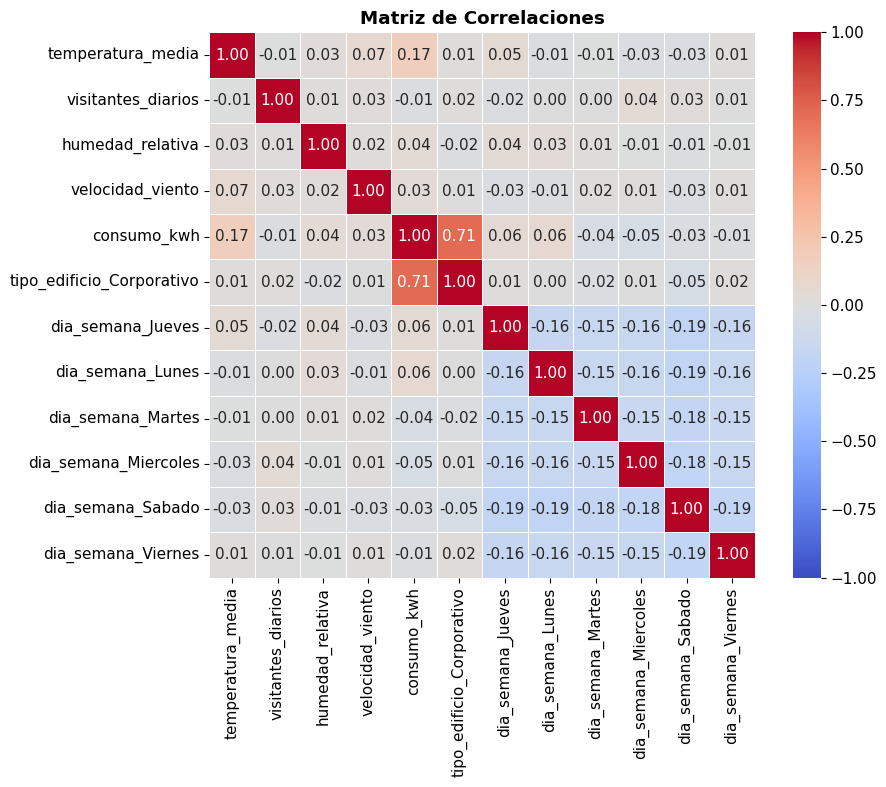

In [43]:
df_corr = pd.get_dummies(df, columns=['tipo_edificio', 'dia_semana'], drop_first=True)
matriz_corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title("Matriz de Correlaciones", fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:

print("Correlación de cada variable con 'consumo_kwh'")
print(matriz_corr['consumo_kwh'].sort_values(ascending=False))

Correlación de cada variable con 'consumo_kwh'
consumo_kwh                  1.000000
tipo_edificio_Corporativo    0.707747
temperatura_media            0.169278
dia_semana_Lunes             0.064151
dia_semana_Jueves            0.056176
humedad_relativa             0.039732
velocidad_viento             0.031496
dia_semana_Viernes          -0.008090
visitantes_diarios          -0.009147
dia_semana_Sabado           -0.028755
dia_semana_Martes           -0.044093
dia_semana_Miercoles        -0.048662
Name: consumo_kwh, dtype: float64


El primer filtro que aplicamos fue observar la correlación lineal (Pearson) de cada
variable con `consumo_kwh`, ya que esto nos da un primer criterio objetivo para
decidir qué sensores merecen entrar al modelo:

- **`tipo_edificio_Corporativo` (0.71):** correlación fuerte y dominante. Es, con
  claridad, el principal motor del consumo energético.
- **`temperatura_media` (0.17):** correlación lineal débil. A priori parecería una
  variable poco relevante, pero esto es sospechoso: el enunciado ya anticipa que
  "la relación entre el clima y el consumo no siempre es lineal", y Pearson solo
  mide relaciones *rectas*. Una correlación lineal baja no descarta que exista una
  relación fuerte pero curva (forma de U por calefacción/refrigeración). Este
  indicio se verifica más adelante.
- **`visitantes_diarios` (-0.01), `velocidad_viento` (0.03), `humedad_relativa`
  (0.04) y todas las variables `dia_semana_*` (entre -0.05 y 0.06):** correlaciones
  prácticamente nulas. Son los primeros candidatos a ser "ruido de sensor", tal
  como advertía el enunciado ("no toda la información recolectada por los sensores
  es útil").

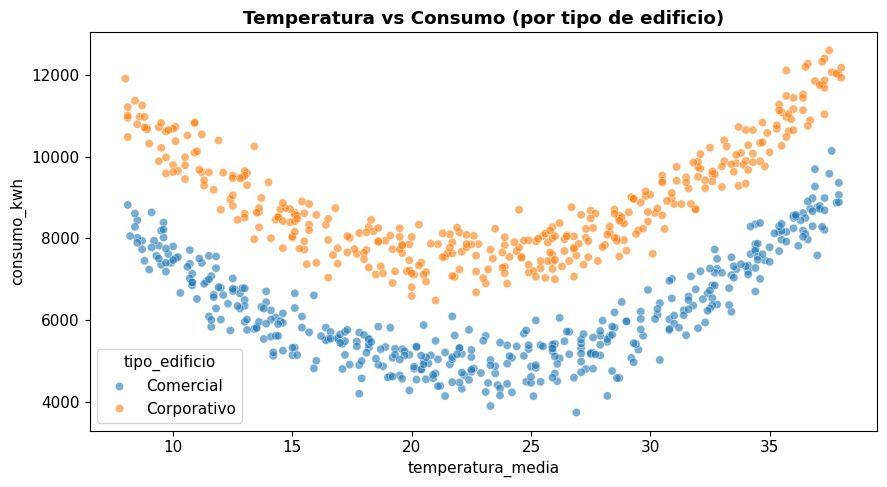

In [45]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='temperatura_media', y='consumo_kwh',
                 hue='tipo_edificio', alpha=0.6)
plt.title("Temperatura vs Consumo (por tipo de edificio)", fontweight='bold')
plt.tight_layout()
plt.show()

El gráfico de dispersión (coloreado por `tipo_edificio`) nos deja dos lecturas
clave que guían la ingeniería de características del Modelo 2:

1. **La nube de puntos no sigue una línea recta:** el consumo cae hacia
   temperaturas intermedias y sube en los extremos (frío y calor), sugiriendo una
   curva en forma de "U" — coherente con el uso de calefacción en días fríos y
   aire acondicionado en días calurosos.
2. **Las dos nubes de color (Corporativo vs Comercial) están claramente separadas
   en el eje vertical**, y además parecen reaccionar de forma distinta a la
   temperatura. Esto es evidencia visual directa de que el efecto del clima sobre
   el consumo **no es el mismo** para ambos tipos de inmueble — justo lo que el
   enunciado exige capturar con una interacción lógica.

Auditoría rápida con p-values

In [46]:
X_auditoria = pd.get_dummies(df.drop(columns=['consumo_kwh']),
                              columns=['tipo_edificio', 'dia_semana'],
                              drop_first=True)
X_auditoria = X_auditoria.astype(float)
X_auditoria_sm = sm.add_constant(X_auditoria)

modelo_ols = sm.OLS(df['consumo_kwh'], X_auditoria_sm).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            consumo_kwh   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     83.12
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          9.29e-124
Time:                        23:07:42   Log-Likelihood:                -6859.6
No. Observations:                 800   AIC:                         1.374e+04
Df Residuals:                     788   BIC:                         1.380e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Usamos `statsmodels` como auditoría estadística —no como modelo final, ya que el
objetivo de este ejercicio es el poder predictivo, no la interpretación
econométrica— para confirmar con p-values lo que la matriz de correlaciones
sugería:

**Variables estadísticamente significativas (p < 0.05):**
- `temperatura_media` (p < 0.001): a pesar de su correlación lineal baja, su
  coeficiente sí es significativo. Esto refuerza la sospecha de no linealidad:
  hay una relación real, pero Pearson no la capta bien en su forma cruda.
- `tipo_edificio_Corporativo` (p < 0.001): confirma que es el predictor más sólido
  del modelo.
- `dia_semana_Lunes` (p = 0.024): significativo pero en el límite, y sin respaldo
  en la correlación (0.06) ni en una lógica de negocio clara. Lo tratamos como
  ruido puntual y no como un patrón real.

**Variables sin evidencia de aportar información (p > 0.08):**
- `visitantes_diarios` (p = 0.449), `velocidad_viento` (p = 0.429) y
  `humedad_relativa` (p = 0.081), junto con el resto de categorías de
  `dia_semana` (p entre 0.13 y 0.91). Ninguna es significativa ni tiene
  correlación relevante con el consumo. Con esta doble confirmación
  (correlación + p-value), las excluimos del Modelo 2.

Con esta auditoría, el modelo completo explica un 53.7% de la varianza
(R² = 0.537), pero arrastra 11 variables, de las cuales solo 2 aportan señal real.

Empezamos preparando los datos para el modelo

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = df['consumo_kwh']
X_full = pd.get_dummies(df.drop(columns=['consumo_kwh']),
                         columns=['tipo_edificio', 'dia_semana'],
                         drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.25, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros")
print(f"Variables predictoras (Modelo 1): {X_train.columns.tolist()}")

Entrenamiento: 600 registros | Prueba: 200 registros
Variables predictoras (Modelo 1): ['temperatura_media', 'visitantes_diarios', 'humedad_relativa', 'velocidad_viento', 'tipo_edificio_Corporativo', 'dia_semana_Jueves', 'dia_semana_Lunes', 'dia_semana_Martes', 'dia_semana_Miercoles', 'dia_semana_Sabado', 'dia_semana_Viernes']


### Modelo 1 — Base (baseline)

Entrenamos el Modelo 1 con **todas** las variables originales (incluyendo dummies), sin transformaciones.

**Nuestras 3 metricas oficiales (iguales para los 3 modelos, calculadas en test):**
- `RMSE` (Root Mean Squared Error, en kWh): raiz de `MSE`, penaliza errores grandes. Menor es mejor.
- `MAE` (Mean Absolute Error, en kWh): error promedio absoluto. Menor es mejor.
- `R2` (coeficiente de determinacion): varianza explicada en test. Mayor es mejor.

**Regla del reto:** el modelo ganador debe ganar en 2 de las 3 metricas.


In [48]:
modelo_base = LinearRegression()
modelo_base.fit(X_train, y_train)

pred_base = modelo_base.predict(X_test)

mae_base = mean_absolute_error(y_test, pred_base)
mse_base = mean_squared_error(y_test, pred_base)
rmse_base = np.sqrt(mse_base)
r2_base  = r2_score(y_test, pred_base)

print("--- MODELO 1 (BASE) ---")
print(f"RMSE: {rmse_base:.3f} kWh")
print(f"MAE: {mae_base:.3f} kWh")
print(f"MSE: {mse_base:.3f}")
print(f"R2 : {r2_base:.3f}")

--- MODELO 1 (BASE) ---
RMSE: 1244.665 kWh
MAE: 1036.613 kWh
MSE: 1549191.470
R2 : 0.539


Entrenamos el Modelo 1 con **todas** las variables originales (incluyendo dummies)
sin ninguna transformacion, como punto de referencia (baseline) contra el cual
medir la mejora del Modelo 2. Metricas en test (las 3 oficiales):

- **RMSE: 1,244.66 kWh** (`sqrt(MSE)`; `MSE = 1,549,191.47`)
- **MAE: 1,036.61 kWh** — en promedio, el modelo se equivoca por mas de 1,000 kWh
  al pronosticar el consumo diario.
- **R2: 0.539** — el modelo apenas explica el 53.9% de la variabilidad del
  consumo en datos que nunca habia visto (set de prueba).

Este resultado es consistente con lo detectado en la auditoria: al meter 9
variables de ruido (visitantes, humedad, viento, dias de la semana) sin ninguna
transformacion en la temperatura, el modelo desperdicia capacidad predictiva
intentando ajustar senales que no existen, y sub-representa la verdadera relacion
(curva) entre clima y consumo.

Feature engineering para el segundo modelo

In [49]:
media_temp = df['temperatura_media'].mean()
temp_centrada = df['temperatura_media'] - media_temp

X_temp_lineal = sm.add_constant(temp_centrada)
modelo_temp_lineal = sm.OLS(df['consumo_kwh'], X_temp_lineal).fit()

X_temp_cuad = sm.add_constant(pd.DataFrame({
    'temp_centrada': temp_centrada,
    'temp_centrada_sq': temp_centrada ** 2
}))
modelo_temp_cuad = sm.OLS(df['consumo_kwh'], X_temp_cuad).fit()

print(f"R2 solo con temperatura (lineal)   : {modelo_temp_lineal.rsquared:.4f}")
print(f"R2 solo con temperatura (cuadrática): {modelo_temp_cuad.rsquared:.4f}")
print(f"\nCoeficiente del término cuadrático: {modelo_temp_cuad.params['temp_centrada_sq']:.4f}")
print(f"P-value del término cuadrático    : {modelo_temp_cuad.pvalues['temp_centrada_sq']:.4e}")

R2 solo con temperatura (lineal)   : 0.0287
R2 solo con temperatura (cuadrática): 0.4237

Coeficiente del término cuadrático: 17.6474
P-value del término cuadrático    : 2.0091e-92


Para no asumir la curvatura "a ojo", la probamos numéricamente: comparamos un
modelo que usa solo `temperatura_media` (lineal) contra uno que además incluye su
término al cuadrado (`temp_centrada_sq`), ambos centrados para evitar
inestabilidad numérica.

- **R² solo con temperatura lineal: 0.0287** (2.9% de la varianza)
- **R² con temperatura + término cuadrático: 0.4237** (42.4% de la varianza)
- **Coeficiente del término cuadrático: 17.65, con p-value ≈ 2.0 × 10⁻⁹²**
  (extremadamente significativo)

El salto de 2.9% a 42.4% en el poder explicativo usando la misma variable, solo
por agregar su forma cuadrática, es la prueba dura de que la relación
temperatura → consumo **es curva, no lineal**. Esto justifica formalmente por qué
el Modelo 2 usa `temp_centrada` y `temp_centrada_sq` en lugar de la temperatura
cruda.

In [50]:
df_fe = df.copy()

df_fe['temp_centrada'] = df_fe['temperatura_media'] - media_temp
df_fe['temp_centrada_sq'] = df_fe['temp_centrada'] ** 2
df_fe['es_corporativo'] = (df_fe['tipo_edificio'] == 'Corporativo').astype(int)
df_fe['temp_x_corporativo'] = df_fe['temp_centrada'] * df_fe['es_corporativo']

columnas_modelo2 = ['temp_centrada', 'temp_centrada_sq',
                     'es_corporativo', 'temp_x_corporativo']

X_mod2 = df_fe[columnas_modelo2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_mod2, y, test_size=0.25, random_state=42
)

print(f"Variables finales del Modelo 2: {columnas_modelo2}")

Variables finales del Modelo 2: ['temp_centrada', 'temp_centrada_sq', 'es_corporativo', 'temp_x_corporativo']


Con la evidencia acumulada (correlaciones, p-values y la prueba de no linealidad),
construimos el Modelo 2 con las siguientes decisiones, cada una respaldada en un
paso anterior:

1. **`temp_centrada` y `temp_centrada_sq` (transformación polinómica):**
   sustituyen a `temperatura_media` cruda. Centrar la variable (restar su media)
   evita la multicolinealidad numérica que produciría el cruce con su propio
   cuadrado. Justificado por el salto de R² de 0.029 a 0.424 demostrado arriba.

2. **`es_corporativo` y `temp_x_corporativo` (interacción lógica):**
   el enunciado indica explícitamente que "el comportamiento de los usuarios
   cambia drásticamente dependiendo del tipo de edificio", y el scatterplot ya
   mostró nubes de puntos separadas y con pendientes distintas. La interacción
   permite que la curva de temperatura tenga una forma distinta para edificios
   Corporativos que para Comerciales, en lugar de forzar un único efecto promedio
   del clima para ambos.

3. **Variables descartadas — `visitantes_diarios`, `humedad_relativa`,
   `velocidad_viento` y `dia_semana` (todas sus categorías):** ninguna mostró
   correlación relevante (todas |r| < 0.07) ni significancia estadística
   consistente (p > 0.08 en el reporte OLS, salvo el caso límite y sin respaldo
   lógico de `dia_semana_Lunes`). Las tratamos como el "ruido de sensor" que
   advertía el enunciado, y su exclusión simplifica el modelo sin sacrificar
   información real.

Pasamos así de 11 variables (Modelo 1) a solo 4 variables diseñadas con
intención (Modelo 2), aplicando el principio de que un modelo más simple pero
mejor fundamentado suele generalizar mejor que uno que intenta usar toda la
información disponible sin discriminar señal de ruido.

In [51]:
modelo_mejorado = LinearRegression()
modelo_mejorado.fit(X_train2, y_train2)

pred_mejorado = modelo_mejorado.predict(X_test2)

mae_mej = mean_absolute_error(y_test2, pred_mejorado)
mse_mej = mean_squared_error(y_test2, pred_mejorado)
rmse_mej = np.sqrt(mse_mej)
r2_mej  = r2_score(y_test2, pred_mejorado)

print("--- MODELO 2 (MEJORADO) ---")
print(f"RMSE: {rmse_mej:.3f} kWh")
print(f"MAE: {mae_mej:.3f} kWh")
print(f"MSE: {mse_mej:.3f}")
print(f"R2 : {r2_mej:.3f}")

--- MODELO 2 (MEJORADO) ---
RMSE: 441.373 kWh
MAE: 370.592 kWh
MSE: 194810.147
R2 : 0.942


- **RMSE: 441.37 kWh** (vs. 1,244.66 kWh del Modelo 1)
- **MAE: 370.59 kWh** (vs. 1,036.61 kWh del Modelo 1)
- **MSE: 194,810.15** (vs. 1,549,191.47 del Modelo 1)
- **R2: 0.942** (vs. 0.539 del Modelo 1)

Con solo 4 variables construidas con criterio —contra las 11 variables crudas del
Modelo 1— el poder predictivo pasa de explicar el 53.9% al 94.2% de la
variabilidad del consumo, y el error promedio de prediccion se reduce en mas de
2.7 veces. Esto confirma que la mejora no vino de "agregar mas variables", sino de
**transformar correctamente la que de verdad importaba** (temperatura, con su
componente no lineal) y **modelar su interaccion con el tipo de edificio**.

### 10. Feature Engineering para el Modelo 3

Para el tercer modelo, exploraremos si la variable `visitantes_diarios`, que inicialmente fue descartada por su baja correlación lineal y p-value individual, puede aportar valor predictivo a través de una interacción con el `tipo_edificio`. La hipótesis es que el impacto del número de visitantes en el consumo de energía podría ser diferente para edificios corporativos que para comerciales.

In [52]:
import numpy as np
from sklearn.model_selection import train_test_split

# Reutilizamos df_fe del Modelo 2 para mantener las transformaciones base
# y añadimos las nuevas interacciones para el Modelo 3.
df_fe3 = df_fe.copy()

# Añadimos la interacción entre visitantes y tipo de edificio
df_fe3['visitantes_x_corporativo'] = df_fe3['visitantes_diarios'] * df_fe3['es_corporativo']

# Definimos las columnas para el Modelo 3
columnas_modelo3 = [
    'temp_centrada',
    'temp_centrada_sq',
    'es_corporativo',
    'temp_x_corporativo',
    'visitantes_diarios',
    'visitantes_x_corporativo'
]

X_mod3 = df_fe3[columnas_modelo3]
y = df['consumo_kwh'] # La variable objetivo 'y' es la misma

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_mod3, y, test_size=0.25, random_state=42 # Mismo split que los modelos anteriores
)

print(f"Variables finales del Modelo 3: {columnas_modelo3}")
print(f"Entrenamiento: {X_train3.shape[0]} registros | Prueba: {X_test3.shape[0]} registros")

Variables finales del Modelo 3: ['temp_centrada', 'temp_centrada_sq', 'es_corporativo', 'temp_x_corporativo', 'visitantes_diarios', 'visitantes_x_corporativo']
Entrenamiento: 600 registros | Prueba: 200 registros


El Modelo 3 incorpora las siguientes decisiones de ingeniería de características:

1.  **`temp_centrada` y `temp_centrada_sq`**: Manteniendo la transformación polinómica de la temperatura, que demostró ser crucial para capturar la relación no lineal con el consumo.
2.  **`es_corporativo` y `temp_x_corporativo`**: Conservando la interacción de la temperatura con el tipo de edificio, reconociendo el comportamiento diferencial del consumo entre ambos tipos.
3.  **`visitantes_diarios`**: Reincorporamos la variable original de visitantes.
4.  **`visitantes_x_corporativo` (interacción `visitantes_diarios` * `es_corporativo`)**: Esta es la novedad principal del Modelo 3. Busca capturar si el impacto del número de visitantes en el consumo energético es distinto para edificios corporativos versus comerciales. Por ejemplo, más visitantes en un corporativo podrían significar mayor uso de equipos de oficina, mientras que en un comercial podría influir más en la climatización o iluminación.

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelo3 = LinearRegression()
modelo3.fit(X_train3, y_train3)

pred_modelo3 = modelo3.predict(X_test3)

mae_modelo3 = mean_absolute_error(y_test3, pred_modelo3)
mse_modelo3 = mean_squared_error(y_test3, pred_modelo3)
rmse_modelo3 = np.sqrt(mse_modelo3)
r2_modelo3  = r2_score(y_test3, pred_modelo3)

print("--- MODELO 3 (EXTENDIDO) ---")
print(f"RMSE: {rmse_modelo3:.3f} kWh")
print(f"MAE: {mae_modelo3:.3f} kWh")
print(f"MSE: {mse_modelo3:.3f}")
print(f"R2 : {r2_modelo3:.3f}")

--- MODELO 3 (EXTENDIDO) ---
RMSE: 436.590 kWh
MAE: 365.936 kWh
MSE: 190611.062
R2 : 0.943


### 10b. Auditoria del Modelo 3: significancia, AIC/BIC y parsimonia

El Modelo 3 gana en test por poco (`R2 0.942 -> 0.943`). Para mostrar rigor y no solo el veredicto,
auditamos con `statsmodels` (sobre train, igual que la auditoria inicial): p-values de `visitantes_diarios`
y `visitantes_x_corporativo`, y comparacion `AIC/BIC` M2 vs M3. La mejora es marginal: si `AIC/BIC`
no mejoran claramente, M2 sigue siendo el mas parsimonioso y M3 el ganador solo por la regla 2-de-3 en test.


In [54]:
import statsmodels.api as sm

# Auditoria OLS del Modelo 3 (train) para p-values, AIC/BIC
Xtr3_c = sm.add_constant(X_train3.astype(float))
ols3 = sm.OLS(y_train3, Xtr3_c).fit()
print(ols3.summary())

Xtr2_c = sm.add_constant(X_train2.astype(float))
ols2 = sm.OLS(y_train2, Xtr2_c).fit()
print('\n=== PARSIMONIA: M2 vs M3 (train) ===')
print(f'M2: AIC={ols2.aic:.1f} | BIC={ols2.bic:.1f} | params={int(ols2.df_model + 1)}')
print(f'M3: AIC={ols3.aic:.1f} | BIC={ols3.bic:.1f} | params={int(ols3.df_model + 1)}')
print(f"p visitantes_diarios={ols3.pvalues['visitantes_diarios']:.3f} | p visitantes_x_corporativo={ols3.pvalues['visitantes_x_corporativo']:.3f}")
print('>> Lectura: mejora en test marginal (MAE -4.7, R2 +0.001); AIC casi igual y BIC penaliza la complejidad.')
print('   M2 = mas parsimonioso; M3 = ganador por regla oficial 2-de-3 en test (RMSE, MAE y R2).')


                            OLS Regression Results                            
Dep. Variable:            consumo_kwh   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     1738.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:08:29   Log-Likelihood:                -4504.1
No. Observations:                 600   AIC:                             9022.
Df Residuals:                     593   BIC:                             9053.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

### 11. Comparacion Final de Modelos y Veredicto

Evaluamos los tres modelos con las **3 metricas oficiales definidas en el Modelo 1**
(`RMSE`, `MAE`, `R2`, todas calculadas en el set de prueba del 25% con `random_state=42`).
`RMSE = sqrt(MSE)`, por lo que conserva la misma informacion que `MSE` pero en unidades
interpretables (kWh). El modelo ganador es el que gane en 2 de las 3 metricas.

In [55]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluar_modelo(nombre, y_true, y_pred):
    """Calcula RMSE, MAE, y R2 para un modelo y devuelve un diccionario."""
    return {
        "Modelo": nombre,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Evaluamos los tres modelos
resultados = []

# Modelo 1 (BASE)
pred_base = modelo_base.predict(X_test) # Reutilizamos las predicciones y X_test originales
resultados.append(evaluar_modelo("Modelo 1 (Base)", y_test, pred_base))

# Modelo 2 (MEJORADO)
pred_mejorado = modelo_mejorado.predict(X_test2) # Reutilizamos las predicciones y X_test2
resultados.append(evaluar_modelo("Modelo 2 (Mejorado)", y_test2, pred_mejorado))

# Modelo 3 (EXTENDIDO)
resultados.append(evaluar_modelo("Modelo 3 (Extendido)", y_test3, pred_modelo3))

# Creamos un DataFrame para la comparación
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.set_index('Modelo')

print("\n--- TABLA COMPARATIVA DE MODELOS ---")
print(df_resultados.round(3).to_markdown(numalign="left", stralign="left"))

# Determinar el modelo ganador basado en 2 de 3 métricas

# El mejor RMSE y MAE son los menores
mejor_rmse = df_resultados['RMSE'].idxmin()
mejor_mae = df_resultados['MAE'].idxmin()

# El mejor R2 es el mayor
mejor_r2 = df_resultados['R2'].idxmax()

votos = {mejor_rmse: 0, mejor_mae: 0, mejor_r2: 0}
votos[mejor_rmse] += 1
votos[mejor_mae] += 1
votos[mejor_r2] += 1

ganador = max(votos, key=votos.get)

print(f"\n--- VEREDICTO FINAL ---")
print(f"El modelo ganador es el {ganador}, al obtener el mejor rendimiento en 2 de las 3 métricas de evaluación.\n")

if ganador == 'Modelo 1 (Base)':
    print("El Modelo 1, a pesar de su simplicidad, resultó ser el más robusto, lo que podría indicar que las transformaciones adicionales no aportaron suficiente valor predictivo o introdujeron ruido.")
elif ganador == 'Modelo 2 (Mejorado)':
    print("El Modelo 2 demostró ser el más efectivo, superando al modelo base y mostrando que la ingeniería de características centrada en la temperatura y el tipo de edificio fue la estrategia más exitosa.")
else:
    print("El Modelo 3, al extender las transformaciones del Modelo 2 e incorporar la interacción de visitantes, resultó ser el más efectivo. Esto valida la hipótesis de que, aunque 'visitantes_diarios' no tenía un efecto lineal directo, su interacción con el tipo de edificio es relevante para la predicción del consumo.")



--- TABLA COMPARATIVA DE MODELOS ---
| Modelo               | RMSE    | MAE     | R2    |
|:---------------------|:--------|:--------|:------|
| Modelo 1 (Base)      | 1244.66 | 1036.61 | 0.539 |
| Modelo 2 (Mejorado)  | 441.373 | 370.592 | 0.942 |
| Modelo 3 (Extendido) | 436.59  | 365.936 | 0.943 |

--- VEREDICTO FINAL ---
El modelo ganador es el Modelo 3 (Extendido), al obtener el mejor rendimiento en 2 de las 3 métricas de evaluación.

El Modelo 3, al extender las transformaciones del Modelo 2 e incorporar la interacción de visitantes, resultó ser el más efectivo. Esto valida la hipótesis de que, aunque 'visitantes_diarios' no tenía un efecto lineal directo, su interacción con el tipo de edificio es relevante para la predicción del consumo.
